In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\orkea\OneDrive\Desktop\store_customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    str    
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 39.2 KB


In [3]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [4]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Annual Income (k$)"] = df["Annual Income (k$)"].fillna(df["Annual Income (k$)"].median())

df["Spending Score (1-100)"] = df["Spending Score (1-100)"].fillna(df["Spending Score (1-100)"].median())

In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.to_csv("clean_store_customers.csv", index=False)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

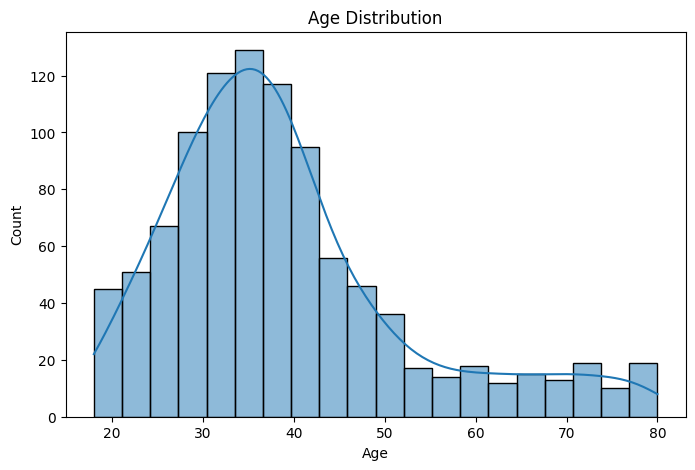

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

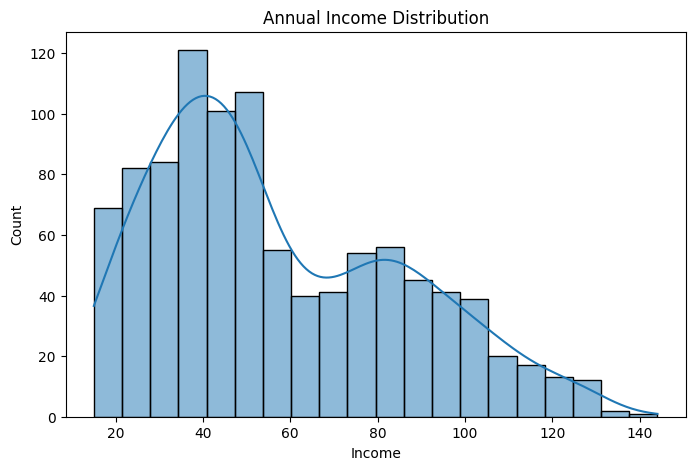

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")

plt.show()

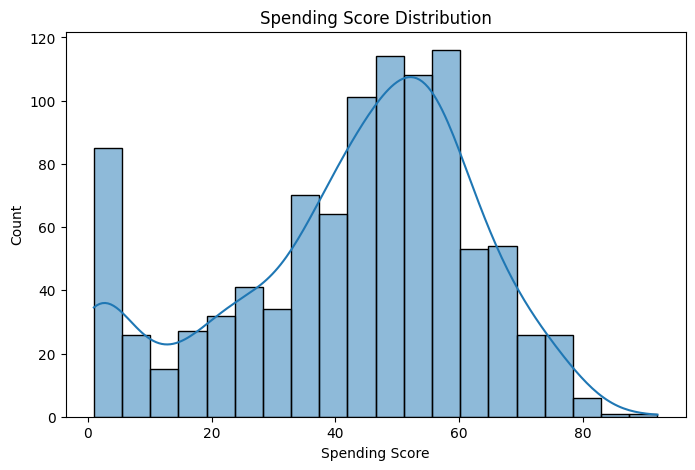

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")

plt.show()

In [11]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]

In [12]:
from sklearn.cluster import KMeans

In [13]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

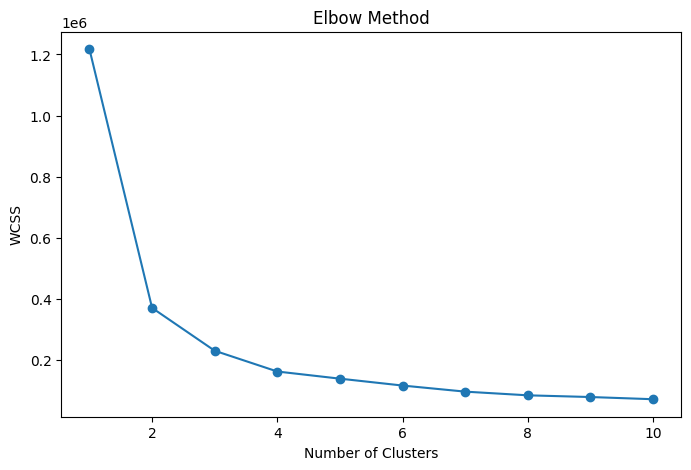

In [14]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [15]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

y_pred = kmeans.fit_predict(X)

In [16]:
df['Cluster'] = y_pred

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1000,M,39.0,59.9,58.0,2
1,1001,M,34.0,48.4,37.0,2
2,1002,F,40.0,70.5,26.0,0
3,1003,F,47.0,81.1,30.0,0
4,1004,F,33.0,42.1,58.0,1


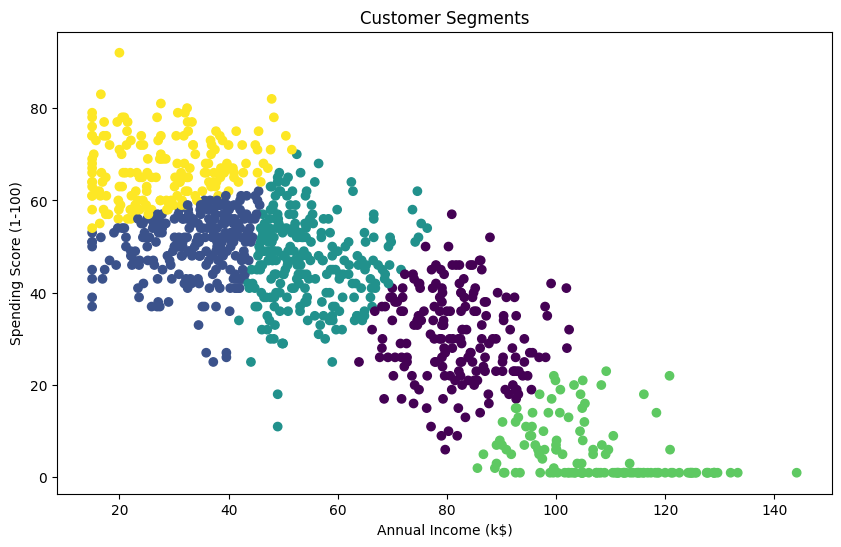

In [17]:
plt.figure(figsize=(10,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_pred
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments")

plt.show()

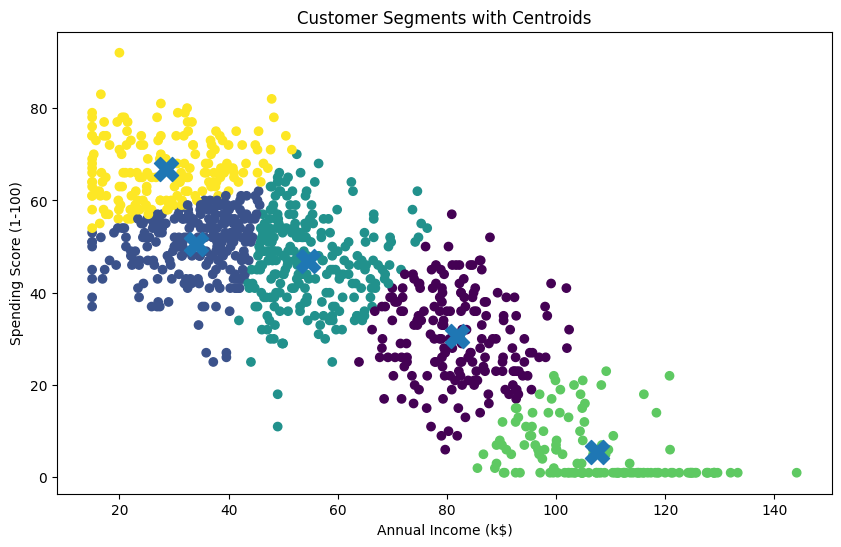

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_pred
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments with Centroids")

plt.show()

In [19]:
df['Cluster'].value_counts()

Cluster
1    251
2    248
0    191
4    176
3    134
Name: count, dtype: int64

In [20]:
print("Customer Segmentation Project Completed Successfully!")
print("Customers were grouped into 5 clusters based on Income and Spending Score.")

Customer Segmentation Project Completed Successfully!
Customers were grouped into 5 clusters based on Income and Spending Score.
